(51,)
(31,)
epsilon=10.0 delta=7.8 chi=-0.1 kappa=0.9500000000000001
[-5.97661493  9.49228877] [ -8.5060855  -10.33063375]


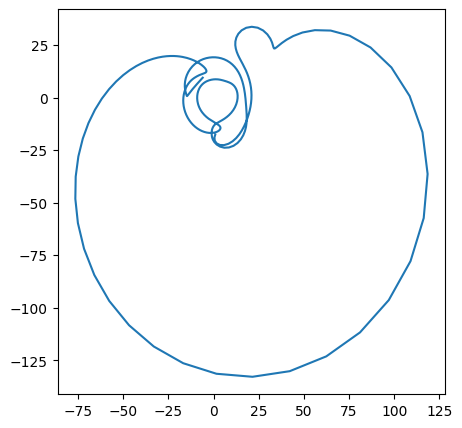

In [31]:
import numpy as np
import scipy


from metastable.state import FixedPointMap
from metastable.eom import EOM, Params
from metastable.manifold_inverses import calculate_manifold_inverses
from metastable.incoming_quantum_vector import extend_to_keldysh_state


fixed_point_map = FixedPointMap.load("/home/paul/Projects/keldysh/metastable/scratch/map.npz")
epsilon_idx = 50
kappa_idx = 19
params = Params(
    epsilon=fixed_point_map.epsilon_linspace[epsilon_idx],
    kappa=fixed_point_map.kappa_linspace[kappa_idx],
    delta=fixed_point_map.delta,
    chi=fixed_point_map.chi,
)
eom = EOM(params=params)
classical_saddle_point = fixed_point_map.fixed_points[epsilon_idx, kappa_idx, 0]
classical_focus_point = fixed_point_map.fixed_points[epsilon_idx, kappa_idx, 1]
print(fixed_point_map.epsilon_linspace.shape)
print(fixed_point_map.kappa_linspace.shape)
print(params)
print(classical_saddle_point, classical_focus_point)


keldysh_saddle_point = extend_to_keldysh_state(classical_saddle_point)
keldysh_focus_point = extend_to_keldysh_state(classical_focus_point)
_, saddle_point_unstable_manifold_inverse = calculate_manifold_inverses(
    keldysh_saddle_point, params
)
focus_point_stable_manifold_inverse, _ = calculate_manifold_inverses(
    keldysh_focus_point, params
)
focus_point_bc_vectors = focus_point_stable_manifold_inverse + np.dot(np.array([[0,1],[-1,0]]),focus_point_stable_manifold_inverse)

def boundary_condition_func(ya, yb):
    return np.hstack(
        [
            np.abs(np.dot(focus_point_bc_vectors, ya - keldysh_focus_point)),
            np.abs(np.dot(saddle_point_unstable_manifold_inverse, yb - keldysh_saddle_point)),
        ]
    )


t_guess = np.linspace(0.0, 8.0, 10001)
y_guess = (
    keldysh_focus_point[:, np.newaxis]
    + t_guess[np.newaxis, :]
    * (keldysh_saddle_point - keldysh_focus_point)[:, np.newaxis]
    / t_guess[-1]
)
wrapper = lambda x, y: eom.y_dot_func(y)
jac_wrapper = lambda x, y: eom.jacobian_func(y)
res = scipy.integrate.solve_bvp(
    wrapper, boundary_condition_func, t_guess, y_guess, tol=3e-14, max_nodes=2000000, fun_jac=jac_wrapper
)




import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,1,figsize=(5, 5))
t_plot = np.linspace(0, t_guess[-1], 1001)
y0_plot = res.sol(t_plot)[0]
y1_plot = res.sol(t_plot)[1]
axes.plot(y0_plot,y1_plot)
plt.show()

In [56]:
jacobian = eom.jacobian_func(keldysh_saddle_point)
eigenvalues, eigenvectors = np.linalg.eig(jacobian)
delta = 1e-5
y0 = keldysh_saddle_point + delta*eigenvectors[:,2]
ivp_wrapper = lambda x, y: -eom.y_dot_func(y)

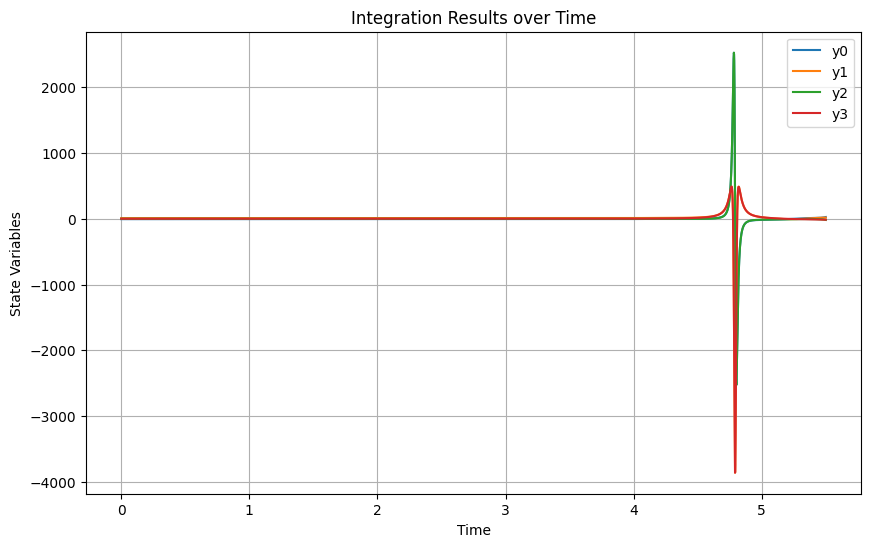

In [79]:
t1 = 5.5

res_ivp = scipy.integrate.solve_ivp(
    ivp_wrapper,
    t_span=(0.0, t1),
    y0=y0,
    method='RK45',  # Default method, change if needed
    t_eval=np.linspace(0.0, t1, 5000)  # Optional: for smoother plot results
)

# Plotting results
plt.figure(figsize=(10, 6))
plt.plot(res_ivp.t, res_ivp.y.T)
plt.title('Integration Results over Time')
plt.xlabel('Time')
plt.ylabel('State Variables')
plt.grid(True)
plt.legend(['y' + str(i) for i in range(res_ivp.y.shape[0])])
plt.show()

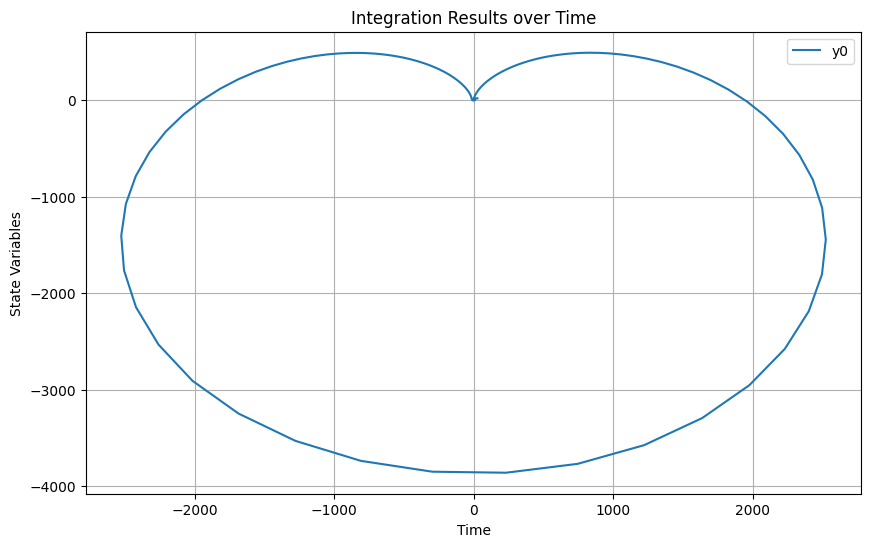

In [80]:
# Plotting results
plt.figure(figsize=(10, 6))
plt.plot(res_ivp.y[0,:], res_ivp.y[1,:])
plt.title('Integration Results over Time')
plt.xlabel('Time')
plt.ylabel('State Variables')
plt.grid(True)
plt.legend(['y' + str(i) for i in range(res.y.shape[0])])
plt.show()

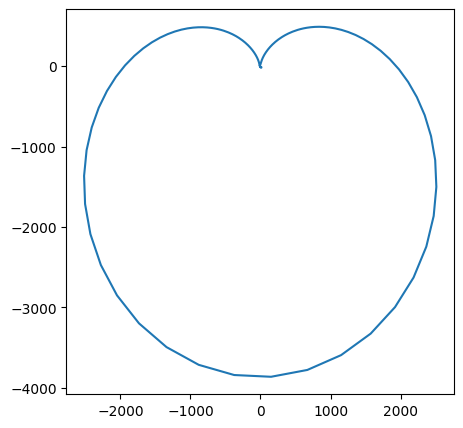

In [86]:
wrapper = lambda x, y: eom.y_dot_func(y)
jac_wrapper = lambda x, y: eom.jacobian_func(y)
res_final = scipy.integrate.solve_bvp(
    wrapper, boundary_condition_func, res_ivp.t, res_ivp.y[:,::-1], tol=3e-14, max_nodes=10000
)




import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,1,figsize=(5, 5))
t_plot = np.linspace(0, res_final.x[-1], 5001)
y0_plot = res_final.sol(t_plot)[0]
y1_plot = res_final.sol(t_plot)[1]
axes.plot(y0_plot,y1_plot)
plt.show()